# Batch Normalizationの導入

---
## 目的
多層パーセプトロン (Multi Layer Perceptoron; MLP) を用いたMNISTデータセットの認識実験において，Batch Normalizationの効果を理解する．

## モジュールのインポート
プログラムの実行に必要なモジュールをインポートします．

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gzip

## データセットのダウンロードと読み込みとサンプル数の削減

まずはじめに，`wget`コマンドを使用して，MNISTデータセットをダウンロードします．

In [ ]:
!wget -q https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz -O train-images-idx3-ubyte.gz
!wget -q https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz -O train-labels-idx1-ubyte.gz
!wget -q https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz -O t10k-images-idx3-ubyte.gz
!wget -q https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz -O t10k-labels-idx1-ubyte.gz

次に，ダウンロードしたファイルからデータを読み込みます．詳細は前回までのプログラムを確認してください．


ここで，学習データを削減します．
今回は1000サンプルになるように，先頭から1000個の学習データとラベルを取得します．

In [2]:
# load images
with gzip.open('train-images-idx3-ubyte.gz', 'rb') as f:
    x_train = np.frombuffer(f.read(), np.uint8, offset=16)
x_train = x_train.reshape(-1, 784)

with gzip.open('t10k-images-idx3-ubyte.gz', 'rb') as f:
    x_test = np.frombuffer(f.read(), np.uint8, offset=16)
x_test = x_test.reshape(-1, 784)

with gzip.open('train-labels-idx1-ubyte.gz', 'rb') as f:
    y_train = np.frombuffer(f.read(), np.uint8, offset=8)

with gzip.open('t10k-labels-idx1-ubyte.gz', 'rb') as f:
    y_test = np.frombuffer(f.read(), np.uint8, offset=8)

x_train = x_train[0:1000, :]
y_train = y_train[0:1000]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1000, 784) (1000,)
(10000, 784) (10000,)


## ネットワークモデルの定義
次に，ニューラルネットワーク（多層パーセプトロン）を定義します．

まずはじめに，ネットワークの定義に必要な関数を定義します．

In [3]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    grad = np.zeros(x.shape)
    grad[x > 0] = 1
    return grad

def softmax(x):
    if x.ndim == 2:
        x = x.T
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T 
    else:
        return np.exp(x) / np.sum(np.exp(x))

次に，上で定義した関数を用いてネットワークを定義します． ここでは，Batch Normalizationを適用する場合としない場合の2種類の5層の多層パーセプトロンを定義します．

まず，Batch Normaliztionを適用しないネットワーク`MLP`を定義します．詳細については前回までの資料を確認してください．

In [4]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size, w_std=0.01):
        self.w1 = w_std * np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros(hidden_size)
        self.w2 = w_std * np.random.randn(hidden_size, hidden_size)
        self.b2 = np.zeros(hidden_size)
        self.w3 = w_std * np.random.randn(hidden_size, output_size)
        self.b3 = np.zeros(output_size)

        self.act = relu
        self.act_grad = relu_grad
        
        self.grads = {}

    def forward(self, x):
        self.h1 = np.dot(x, self.w1) + self.b1
        self.h2 = self.act(self.h1)
        self.h3 = np.dot(self.h2, self.w2) + self.b2
        self.h4 = self.act(self.h3)
        self.h5 = np.dot(self.h4, self.w3) + self.b3
        self.y = softmax(self.h5)
        return self.y

    def backward(self, x, t):
        batch_size = x.shape[0]
        self.grads = {}
        
        t = np.identity(10)[t]
        dy = (self.y - t) / batch_size

        self.grads['w3'] = np.dot(self.h4.T, dy)
        self.grads['b3'] = np.sum(dy, axis=0)

        d_h4 = np.dot(dy, self.w3.T)
        d_h3 = self.act_grad(self.h3) * d_h4
        self.grads['w2'] = np.dot(self.h2.T, d_h3)
        self.grads['b2'] = np.sum(d_h3, axis=0)
        
        d_h2 = np.dot(d_h3, self.w2.T)
        d_h1 = self.act_grad(self.h1) * d_h2
        self.grads['w1'] = np.dot(x.T, d_h1)
        self.grads['b1'] = np.sum(d_h1, axis=0)
        
    def update_parameters(self, lr=0.1):
        self.w1 -= lr * self.grads['w1']
        self.b1 -= lr * self.grads['b1']
        self.w2 -= lr * self.grads['w2']
        self.b2 -= lr * self.grads['b2']  
        self.w3 -= lr * self.grads['w3']
        self.b3 -= lr * self.grads['b3']  

次に，Batch Normalizationを適用する場合のネットワーク`MLPBatchNorm`を定義します．


`__init__`関数でネットワークの初期化を行う際に，各中間層（全結合層）後に適用するBatch Norm.のパラメータを定義し，初期化します．


In [5]:
class MLPBatchNorm:

    def __init__(self, input_size, hidden_size, output_size, w_std=0.01):
        self.w1 = w_std * np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros(hidden_size)
        self.w2 = w_std * np.random.randn(hidden_size, hidden_size)
        self.b2 = np.zeros(hidden_size)
        self.w3 = w_std * np.random.randn(hidden_size, output_size)
        self.b3 = np.zeros(output_size)

        self.act = relu
        self.act_grad = relu_grad
        
        # Batch Normalization（1層目）の初期化
        self.bn_input_size1 = None
        self.gamma1 = np.ones(hidden_size)
        self.beta1 = np.zeros(hidden_size)
        self.momentum1 = 0.9
        self.running_mean1 = None
        self.running_var1 = None
        self.batch_size1 = None
        self.xc1 = None
        self.std1 = None

        # Batch Normalization（2層目）の初期化
        self.bn_input_size2 = None
        self.gamma2 = np.ones(hidden_size)
        self.beta2 = np.zeros(hidden_size)
        self.momentum2 = 0.9
        self.running_mean2 = None
        self.running_var2 = None
        self.batch_size2 = None
        self.xc2 = None
        self.std2 = None

        self.grads = {}

    def forward(self, x, train_mode=True):
        self.h1 = np.dot(x, self.w1) + self.b1

        # Batch Normalization 1層目 =======
        N, D = self.h1.shape
        if self.running_mean1 is None:
            self.running_mean1 = np.zeros(D)
            self.running_var1 = np.zeros(D)

        if train_mode:
            mu1 = self.h1.mean(axis=0)
            xc1 = self.h1 - mu1
            var1 = np.mean(xc1**2, axis=0)
            std1 = np.sqrt(var1 + 10e-7)
            xn1 = xc1 / std1

            self.batch_size1 = self.h1.shape[0]
            self.xc1 = xc1
            self.xn1 = xn1
            self.std1 = std1
            self.running_mean1 = self.momentum1 * self.running_mean1 + (1 - self.momentum1) * mu1
            self.running_var1 = self.momentum1 * self.running_var1 + (1 - self.momentum1) * var1
        else:
            xc1 = self.h1 - self.running_mean1
            xn1 = xc1 / ((np.sqrt(self.running_var1 + 10e-7)))
        self.h2 = self.gamma1 * xn1 + self.beta1
        # ================================

        self.h3 = self.act(self.h2)
        self.h4 = np.dot(self.h3, self.w2) + self.b2

        # Batch Normalization 2層目 =======
        N, D = self.h4.shape
        if self.running_mean2 is None:
            self.running_mean2 = np.zeros(D)
            self.running_var2 = np.zeros(D)

        if train_mode:
            mu2 = self.h4.mean(axis=0)
            xc2 = self.h4 - mu2
            var2 = np.mean(xc2**2, axis=0)
            std2 = np.sqrt(var2 + 10e-7)
            xn2 = xc2 / std2

            self.batch_size2 = self.h4.shape[0]
            self.xc2 = xc2
            self.xn2 = xn2
            self.std2 = std2
            self.running_mean2 = self.momentum2 * self.running_mean2 + (1 - self.momentum2) * mu2
            self.running_var2 = self.momentum2 * self.running_var2 + (1 - self.momentum2) * var2
        else:
            xc2 = self.h4 - self.running_mean2
            xn2 = xc2 / ((np.sqrt(self.running_var2 + 10e-7)))
        self.h5 = self.gamma2 * xn2 + self.beta2
        # ================================

        self.h6 = self.act(self.h5)
        self.h7 = np.dot(self.h6, self.w3) + self.b3
        self.y = softmax(self.h7)
        return self.y

    def backward(self, x, t):
        batch_size = x.shape[0]
        self.grads = {}
        
        t = np.identity(10)[t]
        dy = (self.y - t) / batch_size

        self.grads['w3'] = np.dot(self.h6.T, dy)
        self.grads['b3'] = np.sum(dy, axis=0)

        d_h6 = np.dot(dy, self.w3.T)
        d_h5 = self.act_grad(self.h5) * d_h6

        # Batch Norm. 勾配　2層目 ==========
        self.grads['beta2'] = d_h5.sum(axis=0)
        self.grads['gamma2'] = np.sum(self.xn2 * d_h5, axis=0)
        dxn2 = self.gamma2 * d_h5
        dxc2 = dxn2 / self.std2
        dstd2 = -np.sum((dxn2 * self.xc2) / (self.std2 * self.std2), axis=0)
        dvar2 = 0.5 * dstd2 / self.std2
        dxc2 += (2.0 / self.batch_size2) * self.xc2 * dvar2
        dmu2 = np.sum(dxc2, axis=0)
        d_h4 = dxc2 - dmu2 / self.batch_size2
        # ================================

        self.grads['w2'] = np.dot(self.h3.T, d_h4)
        self.grads['b2'] = np.sum(d_h4, axis=0)
        
        d_h3 = np.dot(d_h4, self.w2.T)
        d_h2 = self.act_grad(self.h2) * d_h3

        # Batch Norm. 勾配　1層目 ==========
        self.grads['beta1'] = d_h2.sum(axis=0)
        self.grads['gamma1'] = np.sum(self.xn1 * d_h2, axis=0)
        dxn1 = self.gamma1 * d_h2
        dxc1 = dxn1 / self.std1
        dstd1 = -np.sum((dxn1 * self.xc1) / (self.std1 * self.std1), axis=0)
        dvar1 = 0.5 * dstd1 / self.std1
        dxc1 += (2.0 / self.batch_size1) * self.xc1 * dvar1
        dmu1 = np.sum(dxc1, axis=0)
        d_h1 = dxc1 - dmu1 / self.batch_size1
        # ================================

        self.grads['w1'] = np.dot(x.T, d_h1)
        self.grads['b1'] = np.sum(d_h1, axis=0)
        
    def update_parameters(self, lr=0.1):
        self.w1 -= lr * self.grads['w1']
        self.b1 -= lr * self.grads['b1']
        self.w2 -= lr * self.grads['w2']
        self.b2 -= lr * self.grads['b2']  
        self.w3 -= lr * self.grads['w3']
        self.b3 -= lr * self.grads['b3']
        self.gamma1 -= lr * self.grads['gamma1']
        self.beta1  -= lr * self.grads['beta1']
        self.gamma2 -= lr * self.grads['gamma2']
        self.beta2  -= lr * self.grads['beta2']

## 学習
サンプル数を削減したMNISTデータセットと作成したネットワークを用いて，２つのネットワークの学習を行います．

まず，学習およびネットワークに関するパラメータを設定します．
学習サンプル数，テストサンプル数および，1回の誤差を算出するデータ数（ミニバッチサイズ）と学習エポック数を定義します．

また，中間層と出力層のユニット数を定義します．
ここでは，入力層のユニット数`input_size`を学習データの次元，中間層のユニット数`hidden_size`128，`output_size`を10とします．

In [6]:
# 学習途中の精度を確認するための関数
def multiclass_classification_accuracy(pred, true):
    clf_res = np.argmax(pred, axis=1)
    return np.sum(clf_res == true).astype(np.float32)

# 学習中の誤差を確認するための関数
def cross_entropy(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 教師データがone-hot-vectorの場合、正解ラベルのインデックスに変換
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

# 学習パラメータ
num_train_data = x_train.shape[0]
num_test_data = x_test.shape[0]
batch_size = 100
epoch_num = 10
learning_rate = 0.01

# ネットワークパラメータ
input_size = x_train.shape[1]
hidden_size = 128
output_size = 10

### Batch Norm.なしのモデルの学習

Batch Norm.無しのネットワークモデルを学習します．
上で定義したパラメータを使用して，ネットワーク`MLP`を初期化し，学習を行います．
学習プログラムの詳細については前回までの資料を参照してください．

In [7]:
model = MLP(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

epoch_list = []
train_loss_list = []
train_accuracy_list = []
test_accuracy_list = []

iteration = 0
for epoch in range(1, epoch_num + 1):
    sum_accuracy, sum_loss = 0.0, 0.0
    
    perm = np.random.permutation(num_train_data)
    for i in range(0, num_train_data, batch_size):
        x_batch = x_train[perm[i:i+batch_size]]
        y_batch = y_train[perm[i:i+batch_size]]
        
        y = model.forward(x_batch)
        sum_accuracy += multiclass_classification_accuracy(y, y_batch)
        sum_loss += cross_entropy(y, y_batch)

        model.backward(x_batch, y_batch)
        model.update_parameters(lr=learning_rate)

        iteration += 1
    
    print("epoch: {} (iteration: {}), mean loss: {}, mean accuracy: {}".format(epoch, iteration,
                                                               sum_loss / num_train_data,
                                                               sum_accuracy / num_train_data))
    
    test_correct_count = 0
    for i in range(num_test_data):
        input = x_test[i:i+1]
        label = y_test[i:i+1]
        y = model.forward(input)
        test_correct_count += multiclass_classification_accuracy(y, label)

    # 学習途中のlossと精度の保存
    epoch_list.append(epoch)
    train_loss_list.append(sum_loss / num_train_data)
    train_accuracy_list.append(sum_accuracy / num_train_data)
    test_accuracy_list.append(test_correct_count / num_test_data)

epoch: 1 (iteration: 10), mean loss: 0.019616235468802427, mean accuracy: 0.39399999380111694
epoch: 2 (iteration: 20), mean loss: 0.012541242304875543, mean accuracy: 0.5680000185966492
epoch: 3 (iteration: 30), mean loss: 0.00931225359914868, mean accuracy: 0.7080000042915344
epoch: 4 (iteration: 40), mean loss: 0.0065142483853964425, mean accuracy: 0.7919999957084656
epoch: 5 (iteration: 50), mean loss: 0.004636633581495851, mean accuracy: 0.8450000286102295
epoch: 6 (iteration: 60), mean loss: 0.003821540074144207, mean accuracy: 0.8859999775886536
epoch: 7 (iteration: 70), mean loss: 0.002584580149157716, mean accuracy: 0.9269999861717224
epoch: 8 (iteration: 80), mean loss: 0.0022517757957288944, mean accuracy: 0.9350000023841858
epoch: 9 (iteration: 90), mean loss: 0.0020533042674673327, mean accuracy: 0.9399999976158142
epoch: 10 (iteration: 100), mean loss: 0.0016445043919177341, mean accuracy: 0.9480000138282776


### Batch Norm.ありのモデルの学習

次にDropoutありのネットワークモデルの学習を行います．

テストデータの認識精度を計算する際は，Batch Normalizationの設定を変更するために，`train_mode=False`と指定することに注意してください．

In [8]:
model_bn = MLPBatchNorm(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

epoch_list_bn = []
train_loss_list_bn = []
train_accuracy_list_bn = []
test_accuracy_list_bn = []

iteration = 0
for epoch in range(1, epoch_num + 1):
    
    sum_accuracy = 0.0
    sum_loss = 0.0
    
    perm = np.random.permutation(num_train_data)
    for i in range(0, num_train_data, batch_size):
        x_batch = x_train[perm[i:i+batch_size]]
        y_batch = y_train[perm[i:i+batch_size]]
        
        y = model_bn.forward(x_batch)
        sum_accuracy += multiclass_classification_accuracy(y, y_batch)
        sum_loss += cross_entropy(y, y_batch)
        
        model_bn.backward(x_batch, y_batch)
        model_bn.update_parameters(lr=learning_rate)

        iteration += 1
    
    print("epoch: {} (iteration: {}), mean loss: {}, mean accuracy: {}".format(epoch, iteration,
                                                               sum_loss / num_train_data,
                                                               sum_accuracy / num_train_data))
    
    test_correct_count = 0
    for i in range(num_test_data):
        input = x_test[i:i+1]
        label = y_test[i:i+1]
        y = model_bn.forward(input, train_mode=False)
        test_correct_count += multiclass_classification_accuracy(y, label)

    # 学習途中のlossと精度の保存
    epoch_list_bn.append(epoch)
    train_loss_list_bn.append(sum_loss / num_train_data)
    train_accuracy_list_bn.append(sum_accuracy / num_train_data)
    test_accuracy_list_bn.append(test_correct_count / num_test_data)

epoch: 1 (iteration: 10), mean loss: 0.02223955684395897, mean accuracy: 0.3330000042915344
epoch: 2 (iteration: 20), mean loss: 0.020170008729137063, mean accuracy: 0.6700000166893005
epoch: 3 (iteration: 30), mean loss: 0.017919848760339654, mean accuracy: 0.7269999980926514
epoch: 4 (iteration: 40), mean loss: 0.015654225646595202, mean accuracy: 0.7609999775886536
epoch: 5 (iteration: 50), mean loss: 0.013646479824640293, mean accuracy: 0.7940000295639038
epoch: 6 (iteration: 60), mean loss: 0.011968279691763643, mean accuracy: 0.8180000185966492
epoch: 7 (iteration: 70), mean loss: 0.010509864547342781, mean accuracy: 0.8379999995231628
epoch: 8 (iteration: 80), mean loss: 0.009154348019344607, mean accuracy: 0.8669999837875366
epoch: 9 (iteration: 90), mean loss: 0.00809539861362278, mean accuracy: 0.8960000276565552
epoch: 10 (iteration: 100), mean loss: 0.007106938059046336, mean accuracy: 0.9210000038146973


## 学習推移のグラフ化

最後に2つのネットワークの学習推移を一つのグラフにまとめてプロットすることで，違いを確認します．

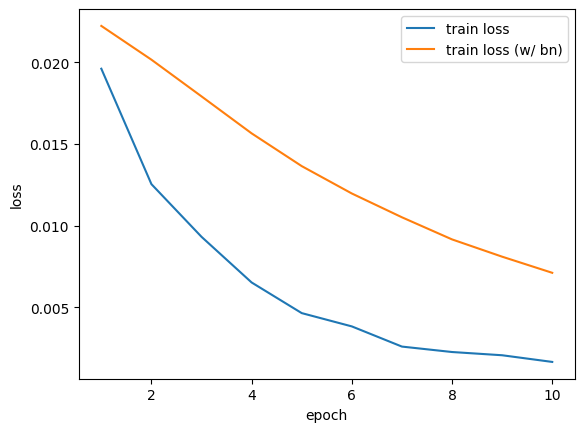

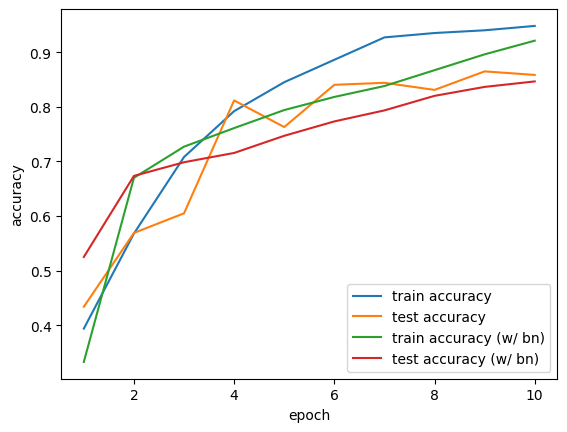

In [9]:
plt.figure()
plt.plot(epoch_list, train_loss_list, label='train loss')
plt.plot(epoch_list_bn, train_loss_list_bn, label='train loss (w/ bn)')
plt.xlabel("epoch")     # x軸ラベル
plt.ylabel("loss")      # y軸ラベル
plt.legend()            # 凡例
plt.show()

plt.figure()
plt.plot(epoch_list, train_accuracy_list, label='train accuracy')
plt.plot(epoch_list, test_accuracy_list, label='test accuracy')
plt.plot(epoch_list_bn, train_accuracy_list_bn, label='train accuracy (w/ bn)')
plt.plot(epoch_list_bn, test_accuracy_list_bn, label='test accuracy (w/ bn)')
plt.xlabel("epoch")     # x軸ラベル
plt.ylabel("accuracy")  # y軸ラベル
plt.legend()            # 凡例
plt.show()